预处理

In [1]:
import numpy as np
from sklearn.preprocessing import KBinsDiscretizer
from scipy.special import expit  # 数值稳定的Sigmoid函数
from sklearn.metrics import accuracy_score, roc_auc_score

def pre_binning(X, n_pre_bins=30, strategy='quantile', bin_edges_reference=None):
    """
    连续特征预分箱与全类独热编码
    修正：验证集完全跟随训练集每个特征的实际箱数，不再强制使用 n_pre_bins。
    """
    n_samples, n_features = X.shape
    bin_edges = []
    X_onehot_filtered = []

    if bin_edges_reference is None:
        # ---------- 训练阶段 ----------
        discretizer = KBinsDiscretizer(
            n_bins=n_pre_bins, encode='onehot-dense',
            strategy=strategy, subsample=None, random_state=42
        )
        X_onehot_raw = discretizer.fit_transform(X)
        bin_edges = discretizer.bin_edges_

        # 根据 bin_edges 的实际长度计算每个特征的箱子数，并丢弃参照箱
        col_start = 0
        feature_bin_dims = []
        for j in range(n_features):
            k_raw = len(bin_edges[j]) - 1  # 原始箱子数（含参照箱）
            # 裁剪出该特征的独热编码并丢弃第一列（参照箱）
            feature_filtered = X_onehot_raw[:, col_start + 1 : col_start + k_raw]
            X_onehot_filtered.append(feature_filtered)
            feature_bin_dims.append(feature_filtered.shape[1])  # = k_raw - 1
            col_start += k_raw

        X_onehot = np.hstack(X_onehot_filtered)
        return X_onehot, bin_edges, feature_bin_dims

    else:
        # ---------- 验证/测试阶段 ----------
        bin_edges = bin_edges_reference
        feature_bin_dims_out = []
        for j in range(n_features):
            edges = bin_edges[j]
            k_raw = len(edges) - 1          # 跟随训练集的实际箱数
            # 分箱索引
            digitized = np.digitize(X[:, j], edges[1:-1])
            digitized = np.clip(digitized, 0, k_raw - 1)
            # 生成全类独热编码
            onehot_raw = np.zeros((n_samples, k_raw))
            onehot_raw[np.arange(n_samples), digitized] = 1
            # 丢弃参照箱（第一列）
            onehot_filtered = onehot_raw[:, 1:]
            X_onehot_filtered.append(onehot_filtered)
            feature_bin_dims_out.append(onehot_filtered.shape[1])

        X_onehot = np.hstack(X_onehot_filtered)
        return X_onehot, bin_edges, feature_bin_dims_out

class BCDOptimalBinning:
    """
    结合L0惩罚的最优分箱BCD算法
    严格对照论文实现，含跨轮次 c_j 指示量修正（论文第VII节）
    """
    def __init__(self, lambda_f=0.01, lambda_b=0.005, max_iter=1000,
                 tol=1e-6, verbose=False, metric='accuracy'):
        self.lambda_f = lambda_f
        self.lambda_b = lambda_b
        self.max_iter = max_iter
        self.tol = tol
        self.verbose = verbose
        self.metric = metric

        self.beta = None
        self.feature_bin_dims = None
        self.n_features = None
        self.bin_edges = None
        self.n_pre_bins = None
        self.history = {
            'loss': [],
            'metric_train': [],
            'metric_val': []
        }
        self.converged = False

    @staticmethod
    def _sigmoid(x):
        return expit(x)

    def _compute_total_loss(self, X, y, eta):
        """
        计算完整目标函数值（公式9）：
        L(β) = L(β) + λf·Σ 1(‖δj‖₀ > 0) + λb·Σ ‖δj‖₀
        注意：论文将λf激活条件等价改写为"存在变点"，即1(‖δj‖₀ > 0)
        """
        n_samples = len(y)
        sigma_eta = self._sigmoid(eta)
        log_likelihood = np.sum(
            y * np.log(sigma_eta + 1e-12) + (1 - y) * np.log(1 - sigma_eta + 1e-12)
        )
        L = -log_likelihood / n_samples

        penalty_f = 0.0
        penalty_b = 0.0
        for j in range(self.n_features):
            beta_j = self.beta[j]
            if self.feature_bin_dims[j] == 0:
                continue
            delta_j = np.diff(beta_j)
            n_change_points = np.sum(np.abs(delta_j) > 1e-12)
            penalty_b += self.lambda_b * n_change_points
            # 严格按论文公式(9)：λf激活条件为"存在变点"（1(‖δj‖₀ > 0)）
            if n_change_points > 0:
                penalty_f += self.lambda_f

        return L + penalty_f + penalty_b

    def _compute_metric(self, X, y, eta=None):
        if eta is None:
            eta = self._compute_linear_predictor(X)
        y_proba = self._sigmoid(eta)
        if self.metric == 'accuracy':
            y_pred = (y_proba >= 0.5).astype(int)
            return accuracy_score(y, y_pred)
        elif self.metric == 'auc':
            return roc_auc_score(y, y_proba)
        else:
            raise ValueError("不支持的评估指标，请选择 'accuracy' 或 'auc'")

    def _compute_linear_predictor(self, X):
        beta_flat = np.concatenate(self.beta)
        if X.shape[1] != beta_flat.shape[0]:
            raise ValueError(
                f"特征维度不匹配！X列数：{X.shape[1]}，系数长度：{beta_flat.shape[0]}"
            )
        return X @ beta_flat

    def _compute_gradient_lipschitz(self, X, y, eta, j, i, feature_start_idx):
        """
        计算梯度与局部Lipschitz常数
        L̂_{j,i} = (1/4)·‖x_col‖²/n  （逻辑回归标准二次上界，论文引理5.1）
        """
        n_samples = len(y)
        x_col = X[:, feature_start_idx + i]
        residual = self._sigmoid(eta) - y
        grad = np.sum(residual * x_col) / n_samples
        L_j_i = 0.25 * np.max(x_col ** 2)  # 使用最大值确保利普希茨条件
        L_j_i = max(L_j_i, 1e-12)
        return grad, L_j_i

    @staticmethod
    def _compute_changepoint_indicator(beta_j):
        """计算特征j的变点指示量 c_j = 1(‖δj‖₀ > 0)"""
        if len(beta_j) < 2:
            return 0
        delta_j = np.diff(beta_j)
        return 1 if np.sum(np.abs(delta_j) > 1e-12) > 0 else 0

    def fit(self, X, y, X_val=None, y_val=None, n_pre_bins=30, binning_strategy='quantile'):
        """
        模型拟合
        核心修正（论文第VII节）：
          - 维护跨轮次的 c_j 指示量数组（上一轮结束后冻结）
          - 每轮开始时对 c_j 拍快照，在该轮内所有特征的更新中使用快照值
          - 每更新完一个特征后，更新该特征对应的 c_j 供下一轮使用
        """
        n_samples, self.n_features = X.shape
        self.n_pre_bins = n_pre_bins

        # 步骤1：预分箱与独热编码
        X_onehot, self.bin_edges, self.feature_bin_dims = pre_binning(
            X, n_pre_bins=n_pre_bins, strategy=binning_strategy
        )

        # 初始化系数（全零）
        self.beta = []
        feature_col_range = []
        current_idx = 0
        for j in range(self.n_features):
            Kj = self.feature_bin_dims[j]
            self.beta.append(np.zeros(Kj))
            feature_col_range.append((current_idx, current_idx + Kj))
            current_idx += Kj

        # =========================================================
        # 【核心修正】初始化 c_j 指示量数组
        # 论文Algorithm 1第1步：c^(0)_j = 0（初始无变点）
        # =========================================================
        c_j = np.zeros(self.n_features, dtype=int)

        eta = self._compute_linear_predictor(X_onehot)

        # 记录初始状态
        initial_loss = self._compute_total_loss(X_onehot, y, eta)
        initial_metric_train = self._compute_metric(X_onehot, y, eta)
        self.history['loss'].append(initial_loss)
        self.history['metric_train'].append(initial_metric_train)

        has_val = (X_val is not None) and (y_val is not None)
        X_val_onehot = None
        if has_val:
            X_val_onehot, _, _ = pre_binning(X_val, n_pre_bins=n_pre_bins,
                                  bin_edges_reference=self.bin_edges)
            initial_metric_val = self._compute_metric(X_val_onehot, y_val)
            self.history['metric_val'].append(initial_metric_val)

        prev_loss = initial_loss

        # 步骤2：BCD主迭代
        for iter_num in range(self.max_iter):

            # =========================================================
            # 【核心修正】在每轮开始时，对 c_j 拍快照
            # 论文第VII节：用上一轮结束后冻结的 c^(s)_j 判断λf激活状态
            # 第1轮：c^(0)_j = 0（全零，与初始化一致）
            # 第2轮起：c_j_snapshot 保存第s轮结束时的状态
            # =========================================================
            c_j_snapshot = c_j.copy()

            for j in range(self.n_features):
                beta_j = self.beta[j].copy()
                Kj = self.feature_bin_dims[j]
                if Kj == 0:
                    continue
                start_idx, _ = feature_col_range[j]

                # 取本轮对应特征j的冻结变点指示量（上一轮结束时的值）
                c_prev = c_j_snapshot[j]

                for i in range(Kj):
                    grad, L_j_i = self._compute_gradient_lipschitz(
                        X_onehot, y, eta, j, i, start_idx
                    )
                    # 近端目标点（公式⊛）
                    r_j_i = beta_j[i] - grad / L_j_i
                    beta_star = r_j_i

                    # 拟合代价（公式14）
                    def F(beta_val, _r=r_j_i, _L=L_j_i):
                        return 0.5 * _L * (_r - beta_val) ** 2

                    if i == 0:
                        # 情形IV（论文公式16/25）：第一个系数，直接令β_{j,1}=r_{j,1}
                        new_beta = beta_star
                    else:
                        # =========================================================
                        # 【核心修正】完整单步比较规则（论文公式26-27）：
                        #
                        # 代价_引入变点 = F(β*) + λf·1(c_prev=0) + λb
                        # 代价_合并     = F(β_{j,i-1}) + λf·c_prev
                        #
                        # 化简后（两侧消去公共λf项）：
                        #   若c_prev=1（λf已激活，两侧均有λf，消去）：
                        #     比较 F(β*)+λb  vs  F(β_{j,i-1})
                        #   若c_prev=0（λf尚未激活，引入时才付）：
                        #     比较 F(β*)+λf+λb  vs  F(β_{j,i-1})
                        #
                        # 注意：比较的β_{j,i-1}是本轮内已更新的当前值（非快照），
                        # 这与论文Algorithm 1一致（i-1步已在本轮内完成更新）
                        # =========================================================
                        if c_prev == 1:
                            # 情形II：λf已激活，额外引入变点只需付λb
                            # 合并的代价需要包括已支付的λf
                            cost_new = F(beta_star) + self.lambda_b
                            cost_merge = F(beta_j[i - 1]) + self.lambda_f
                        else:
                            # 情形I：λf尚未激活，引入第一个变点需同时付λf和λb
                            cost_new = F(beta_star) + self.lambda_f + self.lambda_b
                            cost_merge = F(beta_j[i - 1])

                        new_beta = beta_star if cost_new < cost_merge else beta_j[i - 1]

                    # 增量更新η
                    old_beta = beta_j[i]
                    if np.abs(new_beta - old_beta) > 1e-12:
                        beta_j[i] = new_beta
                        x_col = X_onehot[:, start_idx + i]
                        eta += (new_beta - old_beta) * x_col

                self.beta[j] = beta_j

                # =========================================================
                # 【核心修正】更新本特征的 c_j（供下一轮使用）
                # 论文Algorithm 1 第14行：c^(s+1)_j ← 1(‖δ^(s+1)_j‖₀ > 0)
                # 此处在j特征更新完毕后立即更新c_j[j]，
                # 但本轮内其他特征仍使用c_j_snapshot（上一轮的冻结值）
                # =========================================================
                c_j[j] = self._compute_changepoint_indicator(beta_j)

            # 记录本轮迭代结果
            current_loss = self._compute_total_loss(X_onehot, y, eta)
            current_metric_train = self._compute_metric(X_onehot, y, eta)
            self.history['loss'].append(current_loss)
            self.history['metric_train'].append(current_metric_train)

            metric_val_str = ""
            if has_val:
                current_metric_val = self._compute_metric(X_val_onehot, y_val)
                self.history['metric_val'].append(current_metric_val)
                metric_val_str = (
                    f" | Val {self.metric.capitalize()}: {current_metric_val:.6f}"
                )

            loss_drop = prev_loss - current_loss

            if self.verbose and (iter_num % 2 == 0 or iter_num == self.max_iter - 1):
                print(
                    f"Iter {iter_num + 1:4d} | Loss: {current_loss:.6f} | "
                    f"Drop: {loss_drop:.8f} | "
                    f"Train {self.metric.capitalize()}: {current_metric_train:.6f}"
                    f"{metric_val_str}"
                )

            if 0 <= loss_drop < self.tol:
                if self.verbose:
                    print(f"\n算法收敛！迭代轮数：{iter_num + 1}")
                self.converged = True
                break

            prev_loss = current_loss

        if not self.converged and self.verbose:
            print(f"\n达到最大迭代次数 {self.max_iter}")
        return self

    def get_optimal_binning_structure(self):
        """提取每个特征的最优分箱结果"""
        binning_result = {}
        for j in range(self.n_features):
            beta_j = self.beta[j]
            bin_edges_j = self.bin_edges[j]

            delta_j = np.diff(beta_j)
            change_points = np.where(np.abs(delta_j) > 1e-12)[0] + 1
            pre_cut_points = bin_edges_j[1:-1]
            final_cut_points = pre_cut_points[change_points - 1]  # 修正索引对齐

            final_bins = np.concatenate(
                [[bin_edges_j[0]], final_cut_points, [bin_edges_j[-1]]]
            )

            # 按论文公式(8)累加重建系数（β_{j,i} = β_{j,1} + Σ δ_{j,k}）
            final_coefs = [beta_j[0]] if len(beta_j) > 0 else [0.0]
            current_coef = beta_j[0] if len(beta_j) > 0 else 0.0
            for m in range(1, len(beta_j)):
                if np.abs(delta_j[m - 1]) > 1e-12:
                    current_coef = beta_j[m]
                final_coefs.append(current_coef)

            is_selected = len(change_points) > 0

            binning_result[f"feature_{j + 1}"] = {
                "is_selected": is_selected,
                "final_bins_count": len(final_bins) - 1,  # 区间数=边界点数-1
                "final_bin_intervals": final_bins,
                "final_bin_coefficients": final_coefs,
                "original_beta_vector": beta_j,
                "change_points_indices": change_points,
            }
        return binning_result

    def predict_proba(self, X):
        X_onehot, _, _ = pre_binning(
            X, n_pre_bins=self.n_pre_bins, bin_edges_reference=self.bin_edges
        )
        eta = self._compute_linear_predictor(X_onehot)
        return self._sigmoid(eta)

    def predict(self, X, threshold=0.5):
        y_proba = self.predict_proba(X)
        return (y_proba >= threshold).astype(int)


# -----------------------------------------------------------------------------
# 测试示例（可直接运行）
# -----------------------------------------------------------------------------
if __name__ == "__main__":
    np.random.seed(42)
    n_samples = 1000
    n_features = 5
    X = np.random.randn(n_samples, n_features)

    true_effect = np.zeros(n_samples)
    true_effect += np.where(X[:, 0] < -1, 0.8, np.where(X[:, 0] > 1, -0.8, 0))
    true_effect += np.where(X[:, 1] < 0, 0.6, -0.6)
    y = (expit(true_effect + np.random.randn(n_samples) * 0.1) >= 0.5).astype(int)

    split_idx = int(0.8 * n_samples)
    X_train, X_val = X[:split_idx], X[split_idx:]
    y_train, y_val = y[:split_idx], y[split_idx:]

    print("开始训练，监控指标为 AUC...")
    model = BCDOptimalBinning(
        lambda_f=2e-5, lambda_b=2e-4,  # 调整lambda值以适应更大规模数据
        max_iter=500, tol=1e-6, verbose=True,
        metric='auc'
    )
    model.fit(X_train, y_train, X_val, y_val, n_pre_bins=30)

    print("\n===== 训练历史摘要 =====")
    print(f"初始 Loss: {model.history['loss'][0]:.4f}, "
          f"最终 Loss: {model.history['loss'][-1]:.4f}")
    print(f"初始 Train AUC: {model.history['metric_train'][0]:.4f}, "
          f"最终 Train AUC: {model.history['metric_train'][-1]:.4f}")
    if model.history['metric_val']:
        print(f"初始 Val AUC: {model.history['metric_val'][0]:.4f}, "
              f"最终 Val AUC: {model.history['metric_val'][-1]:.4f}")

    binning_result = model.get_optimal_binning_structure()
    print("\n===== 特征分箱结果 =====")
    for feat_name, feat_info in binning_result.items():
        print(f"{feat_name} | 是否入模：{feat_info['is_selected']} | "
              f"最终分箱区间数：{feat_info['final_bins_count']}")

开始训练，监控指标为 AUC...
Iter    1 | Loss: 0.673229 | Drop: 0.01991774 | Train Auc: 0.960462 | Val Auc: 0.943292
Iter    3 | Loss: 0.635949 | Drop: 0.01796622 | Train Auc: 0.961538 | Val Auc: 0.944614
Iter    5 | Loss: 0.603628 | Drop: 0.01559286 | Train Auc: 0.961800 | Val Auc: 0.944767
Iter    7 | Loss: 0.575477 | Drop: 0.01359877 | Train Auc: 0.961800 | Val Auc: 0.945173
Iter    9 | Loss: 0.550827 | Drop: 0.01192493 | Train Auc: 0.961813 | Val Auc: 0.944817
Iter   11 | Loss: 0.529119 | Drop: 0.01051749 | Train Auc: 0.961813 | Val Auc: 0.945072
Iter   13 | Loss: 0.509890 | Drop: 0.00932992 | Train Auc: 0.961813 | Val Auc: 0.944614
Iter   15 | Loss: 0.492760 | Drop: 0.00832323 | Train Auc: 0.961875 | Val Auc: 0.944614
Iter   17 | Loss: 0.477418 | Drop: 0.00746535 | Train Auc: 0.961875 | Val Auc: 0.944665


/home/test2/miniconda3/envs/cupy-env/lib/python3.10/site-packages/sklearn/preprocessing/_discretization.py:296: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(


Iter   19 | Loss: 0.463604 | Drop: 0.00673018 | Train Auc: 0.961875 | Val Auc: 0.944614
Iter   21 | Loss: 0.451105 | Drop: 0.00609656 | Train Auc: 0.961875 | Val Auc: 0.944767
Iter   23 | Loss: 0.439745 | Drop: 0.00554736 | Train Auc: 0.961875 | Val Auc: 0.944970
Iter   25 | Loss: 0.429377 | Drop: 0.00506869 | Train Auc: 0.961875 | Val Auc: 0.944563
Iter   27 | Loss: 0.419875 | Drop: 0.00464926 | Train Auc: 0.961875 | Val Auc: 0.944512
Iter   29 | Loss: 0.411137 | Drop: 0.00427986 | Train Auc: 0.961875 | Val Auc: 0.944360
Iter   31 | Loss: 0.403072 | Drop: 0.00395293 | Train Auc: 0.961144 | Val Auc: 0.943037
Iter   33 | Loss: 0.395607 | Drop: 0.00366226 | Train Auc: 0.961144 | Val Auc: 0.943088
Iter   35 | Loss: 0.388675 | Drop: 0.00340268 | Train Auc: 0.961144 | Val Auc: 0.943088
Iter   37 | Loss: 0.382222 | Drop: 0.00316992 | Train Auc: 0.961081 | Val Auc: 0.942936
Iter   39 | Loss: 0.376199 | Drop: 0.00296039 | Train Auc: 0.961081 | Val Auc: 0.942885
Iter   41 | Loss: 0.370565 | Dro

In [2]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer

# 读取数据（你原来的读取方式保持不变）
X_train = pd.read_csv('/home/test2/chenzifan/luhongbo/Kaggle_correctbin/simulated_data/毕业论文/分箱联合/分箱真实数据/X_train.csv')
X_test  = pd.read_csv('/home/test2/chenzifan/luhongbo/Kaggle_correctbin/simulated_data/毕业论文/分箱联合/分箱真实数据/X_test.csv')
y_train = pd.read_csv('/home/test2/chenzifan/luhongbo/Kaggle_correctbin/simulated_data/毕业论文/分箱联合/分箱真实数据/y_train.csv')
y_test  = pd.read_csv('/home/test2/chenzifan/luhongbo/Kaggle_correctbin/simulated_data/毕业论文/分箱联合/分箱真实数据/y_test.csv')

# 转为 DataFrame
df_train = X_train.copy() if isinstance(X_train, pd.DataFrame) else pd.DataFrame(X_train)
df_test  = X_test.copy()  if isinstance(X_test, pd.DataFrame)  else pd.DataFrame(X_test)
y_train = np.ravel(y_train)
y_test  = np.ravel(y_test)

print(f"Original shapes: train={df_train.shape}, test={df_test.shape}")

# 1. 分离数值列和分类列
cat_cols = df_train.select_dtypes(include=['object', 'category']).columns.tolist()
num_cols = df_train.select_dtypes(exclude=['object', 'category']).columns.tolist()

# 2. 记录哪些列在训练集中有缺失值（后面要为这些列创建指示器）
missing_num_cols = [c for c in num_cols if df_train[c].isnull().any()]
missing_cat_cols = [c for c in cat_cols if df_train[c].isnull().any()]
print(f"Numerical columns with missing: {len(missing_num_cols)}")
print(f"Categorical columns with missing: {len(missing_cat_cols)}")

# 3. 数值列处理：中位数填充 + 缺失指示器
X_train_num_filled = []
X_test_num_filled = []
missing_ind_train_list = []
missing_ind_test_list = []

if num_cols:
    # 中位数填充
    imputer_num = SimpleImputer(strategy='median')
    X_train_num_filled = imputer_num.fit_transform(df_train[num_cols])
    X_test_num_filled  = imputer_num.transform(df_test[num_cols])
    
    # 为有缺失的数值列生成指示器
    for col in missing_num_cols:
        col_idx = num_cols.index(col)
        # 训练集缺失指示
        missing_ind_train_list.append(df_train[col].isnull().astype(int).values.reshape(-1, 1))
        # 测试集缺失指示
        missing_ind_test_list.append(df_test[col].isnull().astype(int).values.reshape(-1, 1))
else:
    X_train_num_filled = np.empty((len(df_train), 0))
    X_test_num_filled  = np.empty((len(df_test), 0))

# 4. 分类列处理：众数填充 + 独热编码 + 缺失指示器
if cat_cols:
    # 众数填充
    imputer_cat = SimpleImputer(strategy='most_frequent')
    df_train_cat_filled = pd.DataFrame(imputer_cat.fit_transform(df_train[cat_cols]),
                                       columns=cat_cols, index=df_train.index)
    df_test_cat_filled  = pd.DataFrame(imputer_cat.transform(df_test[cat_cols]),
                                       columns=cat_cols, index=df_test.index)
    
    # 独热编码
    encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
    X_train_cat_oh = encoder.fit_transform(df_train_cat_filled)
    X_test_cat_oh  = encoder.transform(df_test_cat_filled)
    
    # 为有缺失的分类列生成指示器
    for col in missing_cat_cols:
        missing_ind_train_list.append(df_train[col].isnull().astype(int).values.reshape(-1, 1))
        missing_ind_test_list.append(df_test[col].isnull().astype(int).values.reshape(-1, 1))
else:
    X_train_cat_oh = np.empty((len(df_train), 0))
    X_test_cat_oh  = np.empty((len(df_test), 0))

# 5. 合并所有部分：填充后的数值 + 数值缺失指示器 + 独热编码后的分类 + 分类缺失指示器
X_train_processed = np.hstack([X_train_num_filled] + missing_ind_train_list + [X_train_cat_oh])
X_test_processed  = np.hstack([X_test_num_filled]  + missing_ind_test_list + [X_test_cat_oh])

# 6. 最终变量命名（方便后续代码兼容）
X_train = X_train_processed
X_val   = X_test_processed
y_val   = y_test

print(f"Preprocessed shapes: train={X_train.shape}, val={X_val.shape}")

Original shapes: train=(45800, 48), test=(15267, 48)
Numerical columns with missing: 26
Categorical columns with missing: 5
Preprocessed shapes: train=(45800, 590), val=(15267, 590)


In [3]:
n_features = X_train.shape[1]
print(f"预处理后特征数: {n_features}")
print(f"训练集形状: {X_train.shape}, 验证集形状: {X_val.shape}")

# 重建 DataFrame，供等频分箱和 OptBinning 使用
df_train = pd.DataFrame(X_train, columns=[f"feat_{i}" for i in range(n_features)])
df_val   = pd.DataFrame(X_val,   columns=[f"feat_{i}" for i in range(n_features)])

# 确保标签是整型
y_train = y_train.astype(int)
y_val   = y_val.astype(int)


预处理后特征数: 590
训练集形状: (45800, 590), 验证集形状: (15267, 590)


In [4]:
# ============================================================================
# 完整实验：两步法 vs BCD vs 等频分箱 vs OptBinning（使用预处理后的真实数据）
# ============================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LassoCV, LogisticRegressionCV, LogisticRegression
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve
from scipy.special import expit
import time
import warnings
warnings.filterwarnings('ignore')

from optbinning import OptimalBinning

# ===================== 0. 数据准备（使用预处理后的真实数据） =====================
# 确保预处理后的变量已存在（若不存在则报错提示）
required_vars = ['X_train', 'X_val', 'y_train', 'y_val', 'df_train', 'df_val']
for var in required_vars:
    if var not in globals():
        raise NameError(f"变量 '{var}' 未找到，请先运行预处理代码。")

n_features = X_train.shape[1]
print(f"使用预处理后的真实数据，特征数: {n_features}")
print(f"训练集大小: {X_train.shape}, 验证集大小: {X_val.shape}")
print(f"正样本比例: 训练集={y_train.mean():.3f}, 验证集={y_val.mean():.3f}")

# ===================== 1. 辅助函数：等频 & OptBinning 分箱 =====================
# (以下函数与之前完全相同，为了完整性保留)
def equal_freq_binning_fit_transform(X_df, bins=5):
    Xb = X_df.copy()
    bin_edges_dict = {}
    for col in Xb.columns:
        if Xb[col].nunique() <= 1:
            Xb[col] = 0
            bin_edges_dict[col] = None
        else:
            binned, edges = pd.qcut(X_df[col], bins, duplicates="drop", retbins=True)
            Xb[col] = binned.cat.codes
            bin_edges_dict[col] = edges
    return Xb.values, bin_edges_dict

def equal_freq_binning_transform(X_df, bin_edges_dict):
    Xb = X_df.copy()
    for col in Xb.columns:
        edges = bin_edges_dict.get(col, None)
        if edges is None or Xb[col].nunique() <= 1:
            Xb[col] = 0
        else:
            binned = pd.cut(X_df[col], bins=edges, include_lowest=True, duplicates="drop")
            Xb[col] = binned.cat.codes
    return Xb.values

def opt_binning_fit_transform(X_df, y, bins=5, top_n=None):
    Xb = X_df.copy()
    opts = []
    iv_list = []
    temp_opts = []
    n_cols = len(Xb.columns)
    print(f"OptBinning: 开始拟合 {n_cols} 个特征...")
    start_fit = time.time()
    for idx, col in enumerate(Xb.columns):
        if (idx+1) % 50 == 0:  # 每50个特征打印一次进度
            elapsed = time.time() - start_fit
            print(f"  已处理 {idx+1}/{n_cols} 个特征，耗时 {elapsed:.1f}s")
        if Xb[col].nunique() <= 1:
            Xb[col] = 0
            temp_opts.append(None)
            iv_list.append(0)
        else:
            opt = OptimalBinning(dtype="numerical", max_n_bins=bins)
            opt.fit(X_df[col], y)
            try:
                iv = opt.binning_table.build()['IV'].iloc[-1]
            except:
                iv = 0
            temp_opts.append(opt)
            iv_list.append(iv)

    if top_n is not None and top_n < len(iv_list):
        selected_idx = set(np.argsort(iv_list)[-top_n:])
    else:
        selected_idx = set(range(len(iv_list)))

    Xb_woe = np.zeros_like(X_df.values, dtype=float)
    for idx in range(n_cols):
        if idx in selected_idx and temp_opts[idx] is not None:
            Xb_woe[:, idx] = temp_opts[idx].transform(X_df.iloc[:, idx], metric="woe")
            opts.append(temp_opts[idx])
        else:
            Xb_woe[:, idx] = 0
            opts.append(None)
    print(f"OptBinning 拟合完成，总耗时 {time.time()-start_fit:.1f}s")
    return Xb_woe, opts

def opt_binning_transform(X_df, opts):
    Xb = X_df.copy()
    for idx, col in enumerate(Xb.columns):
        obj = opts[idx]
        if obj is None or Xb[col].nunique() <= 1:
            Xb[col] = 0
        else:
            Xb[col] = obj.transform(X_df[[col]], metric="woe").flatten()
    return Xb.values

# ===================== 2. 两步法模型类（同上，未修改） =====================
class TwoStepBinningLasso:
    def __init__(self, n_bins=15, C=0.1, random_state=42):
        self.n_bins = n_bins
        self.C = C
        self.random_state = random_state
        self.bin_edges = None
        self.models = None
        self.lasso_model = None
        self.feature_selected = None
        self.feature_importances = None
        self.training_time = None
        
    def cluster_binning(self, X):
        n_samples, n_features = X.shape
        X_binned = np.zeros_like(X)
        self.bin_edges = []
        self.models = []
        for j in range(n_features):
            kmeans = KMeans(n_clusters=self.n_bins, random_state=self.random_state, n_init=10)
            kmeans.fit(X[:, j].reshape(-1, 1))
            centers = kmeans.cluster_centers_.flatten()
            sorted_centers = np.sort(centers)
            bin_edges_j = np.concatenate([
                [X[:, j].min() - 1e-5],
                (sorted_centers[:-1] + sorted_centers[1:]) / 2,
                [X[:, j].max() + 1e-5]
            ])
            bin_edges_j = np.sort(bin_edges_j)
            self.bin_edges.append(bin_edges_j)
            self.models.append(kmeans)
            X_binned[:, j] = np.digitize(X[:, j], bin_edges_j[1:-1])
        return X_binned
    
    def one_hot_encode(self, X_binned, bin_edges=None):
        if bin_edges is None:
            bin_edges = self.bin_edges
        n_samples, n_features = X_binned.shape
        onehot_features = []
        for j in range(n_features):
            Kj = len(bin_edges[j]) - 1
            onehot = np.zeros((n_samples, Kj))
            binned_vals = np.clip(X_binned[:, j].astype(int), 0, Kj-1)
            for i in range(n_samples):
                if binned_vals[i] >= 0 and binned_vals[i] < Kj:
                    onehot[i, binned_vals[i]] = 1
            onehot = onehot[:, 1:]
            onehot_features.append(onehot)
        return np.hstack(onehot_features)
    
    def fit(self, X_train, y_train, X_val=None, y_val=None):
        start_time = time.time()
        print("Two-Step: Step 1 - Cluster binning...")
        X_train_binned = self.cluster_binning(X_train)
        X_train_onehot = self.one_hot_encode(X_train_binned)
        print(f"Two-Step: One-hot dim: {X_train_onehot.shape[1]}")
        print("Two-Step: Step 2 - Lasso selection...")
        self.lasso_model = LogisticRegression(
            penalty='l1', C=self.C, solver='liblinear',
            random_state=self.random_state, max_iter=1000
        )
        self.lasso_model.fit(X_train_onehot, y_train)
        coefficients = self.lasso_model.coef_.flatten()
        n_original_features = len(self.bin_edges)
        n_bins_per_feature = [len(edges)-2 for edges in self.bin_edges]
        self.feature_selected = []
        self.feature_importances = np.zeros(n_original_features)
        start_idx = 0
        for j in range(n_original_features):
            n_bins = n_bins_per_feature[j]
            feature_coefs = coefficients[start_idx:start_idx+n_bins]
            importance = np.max(np.abs(feature_coefs))
            self.feature_importances[j] = importance
            is_selected = np.any(np.abs(feature_coefs) > 1e-6)
            self.feature_selected.append(is_selected)
            start_idx += n_bins
        end_time = time.time()
        self.training_time = end_time - start_time
        print(f"Two-Step: Selected {np.sum(self.feature_selected)}/{n_original_features} features, time={self.training_time:.2f}s")
        return self
    
    def predict_proba(self, X):
        if self.lasso_model is None:
            raise ValueError("Model not fitted")
        n_samples, n_features = X.shape
        X_binned = np.zeros((n_samples, n_features))
        for j in range(n_features):
            X_binned[:, j] = np.digitize(X[:, j], self.bin_edges[j][1:-1])
        X_onehot = self.one_hot_encode(X_binned, self.bin_edges)
        return self.lasso_model.predict_proba(X_onehot)[:, 1]
    
    def predict(self, X, threshold=0.5):
        y_proba = self.predict_proba(X)
        return (y_proba >= threshold).astype(int)
    
    def get_feature_info(self):
        feature_info = {}
        n_original_features = len(self.bin_edges)
        coefficients = self.lasso_model.coef_.flatten()
        n_bins_per_feature = [len(edges)-2 for edges in self.bin_edges]
        start_idx = 0
        for j in range(n_original_features):
            n_bins = n_bins_per_feature[j]
            feature_coefs = coefficients[start_idx:start_idx+n_bins]
            bin_edges_j = self.bin_edges[j]
            bin_intervals = [(bin_edges_j[k], bin_edges_j[k+1]) for k in range(len(bin_edges_j)-1)]
            bin_intervals = bin_intervals[1:]
            feature_info[f"feature_{j+1}"] = {
                "is_selected": self.feature_selected[j],
                "importance": self.feature_importances[j],
                "final_bins_count": n_bins,
                "final_bin_intervals": bin_intervals,
                "bin_coefficients": feature_coefs.tolist()
            }
            start_idx += n_bins
        return feature_info

# ===================== 3. 两步法训练 =====================
print("\n" + "="*50)
print("Two-Step Model Training (开始于 {})".format(time.strftime("%H:%M:%S")))
print("="*50)
two_step_model = TwoStepBinningLasso(n_bins=15, C=0.01)
two_step_model.fit(X_train, y_train, X_val, y_val)

y_train_pred_two_step = two_step_model.predict(X_train)
y_val_pred_two_step = two_step_model.predict(X_val)
y_train_proba_two_step = two_step_model.predict_proba(X_train)
y_val_proba_two_step = two_step_model.predict_proba(X_val)

train_acc_two_step = accuracy_score(y_train, y_train_pred_two_step)
val_acc_two_step = accuracy_score(y_val, y_val_pred_two_step)
train_auc_two_step = roc_auc_score(y_train, y_train_proba_two_step)
val_auc_two_step = roc_auc_score(y_val, y_val_proba_two_step)

print(f"Two-Step Train Acc: {train_acc_two_step:.4f}, Val Acc: {val_acc_two_step:.4f}")
print(f"Two-Step Train AUC: {train_auc_two_step:.4f}, Val AUC: {val_auc_two_step:.4f}")
two_step_selected_features = [i+1 for i, selected in enumerate(two_step_model.feature_selected) if selected]
print(f"Two-Step Selected Features: {two_step_selected_features}")


(CVXPY) Apr 27 01:55:54 AM: Encountered unexpected exception importing solver GLOP:
RuntimeError('Unrecognized new version of ortools (9.15.6755). Expected < 9.15.0. Please open a feature request on cvxpy to enable support for this version.')
(CVXPY) Apr 27 01:55:54 AM: Encountered unexpected exception importing solver PDLP:
RuntimeError('Unrecognized new version of ortools (9.15.6755). Expected < 9.15.0. Please open a feature request on cvxpy to enable support for this version.')


使用预处理后的真实数据，特征数: 590
训练集大小: (45800, 590), 验证集大小: (15267, 590)
正样本比例: 训练集=0.032, 验证集=0.031

Two-Step Model Training (开始于 01:55:54)
Two-Step: Step 1 - Cluster binning...
Two-Step: One-hot dim: 8260
Two-Step: Step 2 - Lasso selection...
Two-Step: Selected 25/590 features, time=4980.47s
Two-Step Train Acc: 0.9678, Val Acc: 0.9689
Two-Step Train AUC: 0.6420, Val AUC: 0.6394
Two-Step Selected Features: [5, 19, 38, 56, 81, 95, 105, 192, 234, 245, 248, 335, 342, 344, 345, 459, 472, 530, 535, 553, 555, 570, 575, 577, 588]


In [5]:

# ===================== 4. BCD 模型训练 =====================
print("\n" + "="*50)
print("BCD Algorithm Training (开始于 {})".format(time.strftime("%H:%M:%S")))
print("="*50)

# !!! 请确保 BCDOptimalBinning 类已在环境中定义（通常为之前的代码定义） !!!
bcd_start_time = time.time()
bcd_model = BCDOptimalBinning(
    lambda_f=3e-6, lambda_b=2e-6,
    max_iter=4000, tol=1e-7, verbose=True,
    metric='auc'
)
bcd_model.fit(X_train, y_train, X_val, y_val, n_pre_bins=20)

bcd_end_time = time.time()
bcd_training_time = bcd_end_time - bcd_start_time

y_train_pred_bcd = bcd_model.predict(X_train)
y_val_pred_bcd = bcd_model.predict(X_val)
y_train_proba_bcd = bcd_model.predict_proba(X_train)
y_val_proba_bcd = bcd_model.predict_proba(X_val)

train_acc_bcd = accuracy_score(y_train, y_train_pred_bcd)
val_acc_bcd = accuracy_score(y_val, y_val_pred_bcd)
train_auc_bcd = roc_auc_score(y_train, y_train_proba_bcd)
val_auc_bcd = roc_auc_score(y_val, y_val_proba_bcd)

binning_result = bcd_model.get_optimal_binning_structure()
bcd_selected_features = []
for j in range(1, n_features + 1):
    feat_name = f"feature_{j}"
    if binning_result[feat_name]["is_selected"]:
        bcd_selected_features.append(j)

print(f"BCD Train Acc: {train_acc_bcd:.4f}, Val Acc: {val_acc_bcd:.4f}")
print(f"BCD Train AUC: {train_auc_bcd:.4f}, Val AUC: {val_auc_bcd:.4f}")
print(f"BCD Time: {bcd_training_time:.2f}s")
print(f"BCD Selected Features: {bcd_selected_features}")
bcd_loss_history = bcd_model.history['loss']

# ===================== 5. 等频分箱 & OptBinning 实验 =====================
print("\n" + "="*50)
print("Equal-frequency & OptBinning Experiments (开始于 {})".format(time.strftime("%H:%M:%S")))
print("="*50)

# 5.1 等频分箱
start_eq = time.time()
print("开始执行等频分箱...")
X_train_eq, eq_edges = equal_freq_binning_fit_transform(df_train, bins=5)
X_val_eq = equal_freq_binning_transform(df_val, eq_edges)
eq_model = LogisticRegressionCV(
    penalty='l1', solver='liblinear', random_state=42, max_iter=2000, cv=5, scoring='roc_auc'
)
eq_model.fit(StandardScaler().fit_transform(X_train_eq), y_train)
y_train_proba_eq = eq_model.predict_proba(StandardScaler().fit_transform(X_train_eq))[:, 1]
y_val_proba_eq = eq_model.predict_proba(StandardScaler().fit_transform(X_val_eq))[:, 1]
eq_time = time.time() - start_eq
train_acc_eq = accuracy_score(y_train, (y_train_proba_eq >= 0.5).astype(int))
val_acc_eq = accuracy_score(y_val, (y_val_proba_eq >= 0.5).astype(int))
train_auc_eq = roc_auc_score(y_train, y_train_proba_eq)
val_auc_eq = roc_auc_score(y_val, y_val_proba_eq)

# ------ 新增：提取等频分箱 L1 选中的特征 ------
eq_coef = eq_model.coef_.flatten()
eq_selected_features = [j + 1 for j in range(n_features) if np.abs(eq_coef[j]) > 1e-5]
print(f"等频分箱 L1 选中特征数: {len(eq_selected_features)}")
print(f"选中特征索引: {eq_selected_features}")

print(f"等频分箱完成，耗时 {eq_time:.2f}s")
print(f"Equal-freq Val AUC: {val_auc_eq:.4f}")

# 5.2 OptBinning
start_opt = time.time()
opt_selection_top = 30   # 可根据需要调整
print("开始执行 OptBinning (IV 筛选前 {} 个特征)...".format(opt_selection_top))
X_train_opt, opt_objects = opt_binning_fit_transform(
    df_train, y_train, bins=5, top_n=opt_selection_top
)
X_val_opt = opt_binning_transform(df_val, opt_objects)

opt_model = LogisticRegressionCV(
    penalty='l1', solver='liblinear', random_state=42, max_iter=2000, cv=5
)
opt_model.fit(StandardScaler().fit_transform(X_train_opt), y_train)
opt_coef = opt_model.coef_.flatten()
opt_selected_features = [j + 1 for j in range(len(opt_coef)) if np.abs(opt_coef[j]) > 1e-5]
print(f"OptBinning L1 选中特征数: {len(opt_selected_features)}")
print(f"选中特征索引: {opt_selected_features}")
y_train_proba_opt = opt_model.predict_proba(StandardScaler().fit_transform(X_train_opt))[:, 1]
y_val_proba_opt = opt_model.predict_proba(StandardScaler().fit_transform(X_val_opt))[:, 1]
opt_time = time.time() - start_opt
train_acc_opt = accuracy_score(y_train, (y_train_proba_opt >= 0.5).astype(int))
val_acc_opt = accuracy_score(y_val, (y_val_proba_opt >= 0.5).astype(int))
train_auc_opt = roc_auc_score(y_train, y_train_proba_opt)
val_auc_opt = roc_auc_score(y_val, y_val_proba_opt)
print(f"OptBinning 完成，总耗时 {opt_time:.2f}s")
print(f"OptBinning Val AUC: {val_auc_opt:.4f}")


# ===================== 6. 汇总所有方法的结果 =====================
methods = ['Two-Step', 'BCD', 'Equal-freq', 'OptBinning']
val_aucs_all = [val_auc_two_step, val_auc_bcd, val_auc_eq, val_auc_opt]
train_aucs_all = [train_auc_two_step, train_auc_bcd, train_auc_eq, train_auc_opt]
val_accs_all = [val_acc_two_step, val_acc_bcd, val_acc_eq, val_acc_opt]
train_accs_all = [train_acc_two_step, train_acc_bcd, train_acc_eq, train_acc_opt]
times_all = [two_step_model.training_time, bcd_training_time, eq_time, opt_time]

# ===================== 7. 可视化（原封不动，仅将标题中的“All 4 Methods”改为英文） =====================
# (代码与之前完全相同，为节省篇幅这里省略，请直接复用之前提供的完整绘图代码)
# 注意：由于真实数据没有“True Effect”列，后面的表格部分会稍有调整（见下文）

# ===================== 8. 打印详细结果表格 =====================
print("\n" + "="*50)
print("Detailed Comparison (All Methods)")
print("="*50)

print("\n--- Performance Metrics ---")
print(f"{'Method':<15} {'Train Acc':>10} {'Val Acc':>10} {'Train AUC':>10} {'Val AUC':>10} {'Time(s)':>10}")
print("-"*65)
for i, method in enumerate(methods):
    print(f"{method:<15} {train_accs_all[i]:>10.4f} {val_accs_all[i]:>10.4f} {train_aucs_all[i]:>10.4f} {val_aucs_all[i]:>10.4f} {times_all[i]:>10.2f}")

print("\n--- Feature Selection (Two-Step / BCD) ---")
print(f"{'Feature':<10} {'Two-Step':<10} {'BCD':<10}")
print("-"*30)
for i in range(1, n_features+1):
    two_sel = "Yes" if i in two_step_selected_features else "No"
    bcd_sel = "Yes" if i in bcd_selected_features else "No"
    print(f"Feature {i:<2} {two_sel:<10} {bcd_sel:<10}")

print(f"\nTwo-Step selected {len(two_step_selected_features)} features, BCD selected {len(bcd_selected_features)} features.")
print("Experiment finished.")


BCD Algorithm Training (开始于 03:20:20)
Iter    1 | Loss: 0.150479 | Drop: 0.54266844 | Train Auc: 0.549613 | Val Auc: 0.527200
Iter    3 | Loss: 0.145766 | Drop: 0.00154430 | Train Auc: 0.555889 | Val Auc: 0.537362
Iter    5 | Loss: 0.143884 | Drop: 0.00078964 | Train Auc: 0.564797 | Val Auc: 0.550331
Iter    7 | Loss: 0.142876 | Drop: 0.00043024 | Train Auc: 0.571859 | Val Auc: 0.561904
Iter    9 | Loss: 0.142290 | Drop: 0.00025800 | Train Auc: 0.577453 | Val Auc: 0.573021
Iter   11 | Loss: 0.141907 | Drop: 0.00017389 | Train Auc: 0.582144 | Val Auc: 0.582166
Iter   13 | Loss: 0.141627 | Drop: 0.00013085 | Train Auc: 0.586419 | Val Auc: 0.589557
Iter   15 | Loss: 0.141403 | Drop: 0.00010726 | Train Auc: 0.590254 | Val Auc: 0.596003
Iter   17 | Loss: 0.141210 | Drop: 0.00009312 | Train Auc: 0.593823 | Val Auc: 0.600922
Iter   19 | Loss: 0.141038 | Drop: 0.00008374 | Train Auc: 0.597083 | Val Auc: 0.604747
Iter   21 | Loss: 0.140881 | Drop: 0.00007687 | Train Auc: 0.600169 | Val Auc: 0.

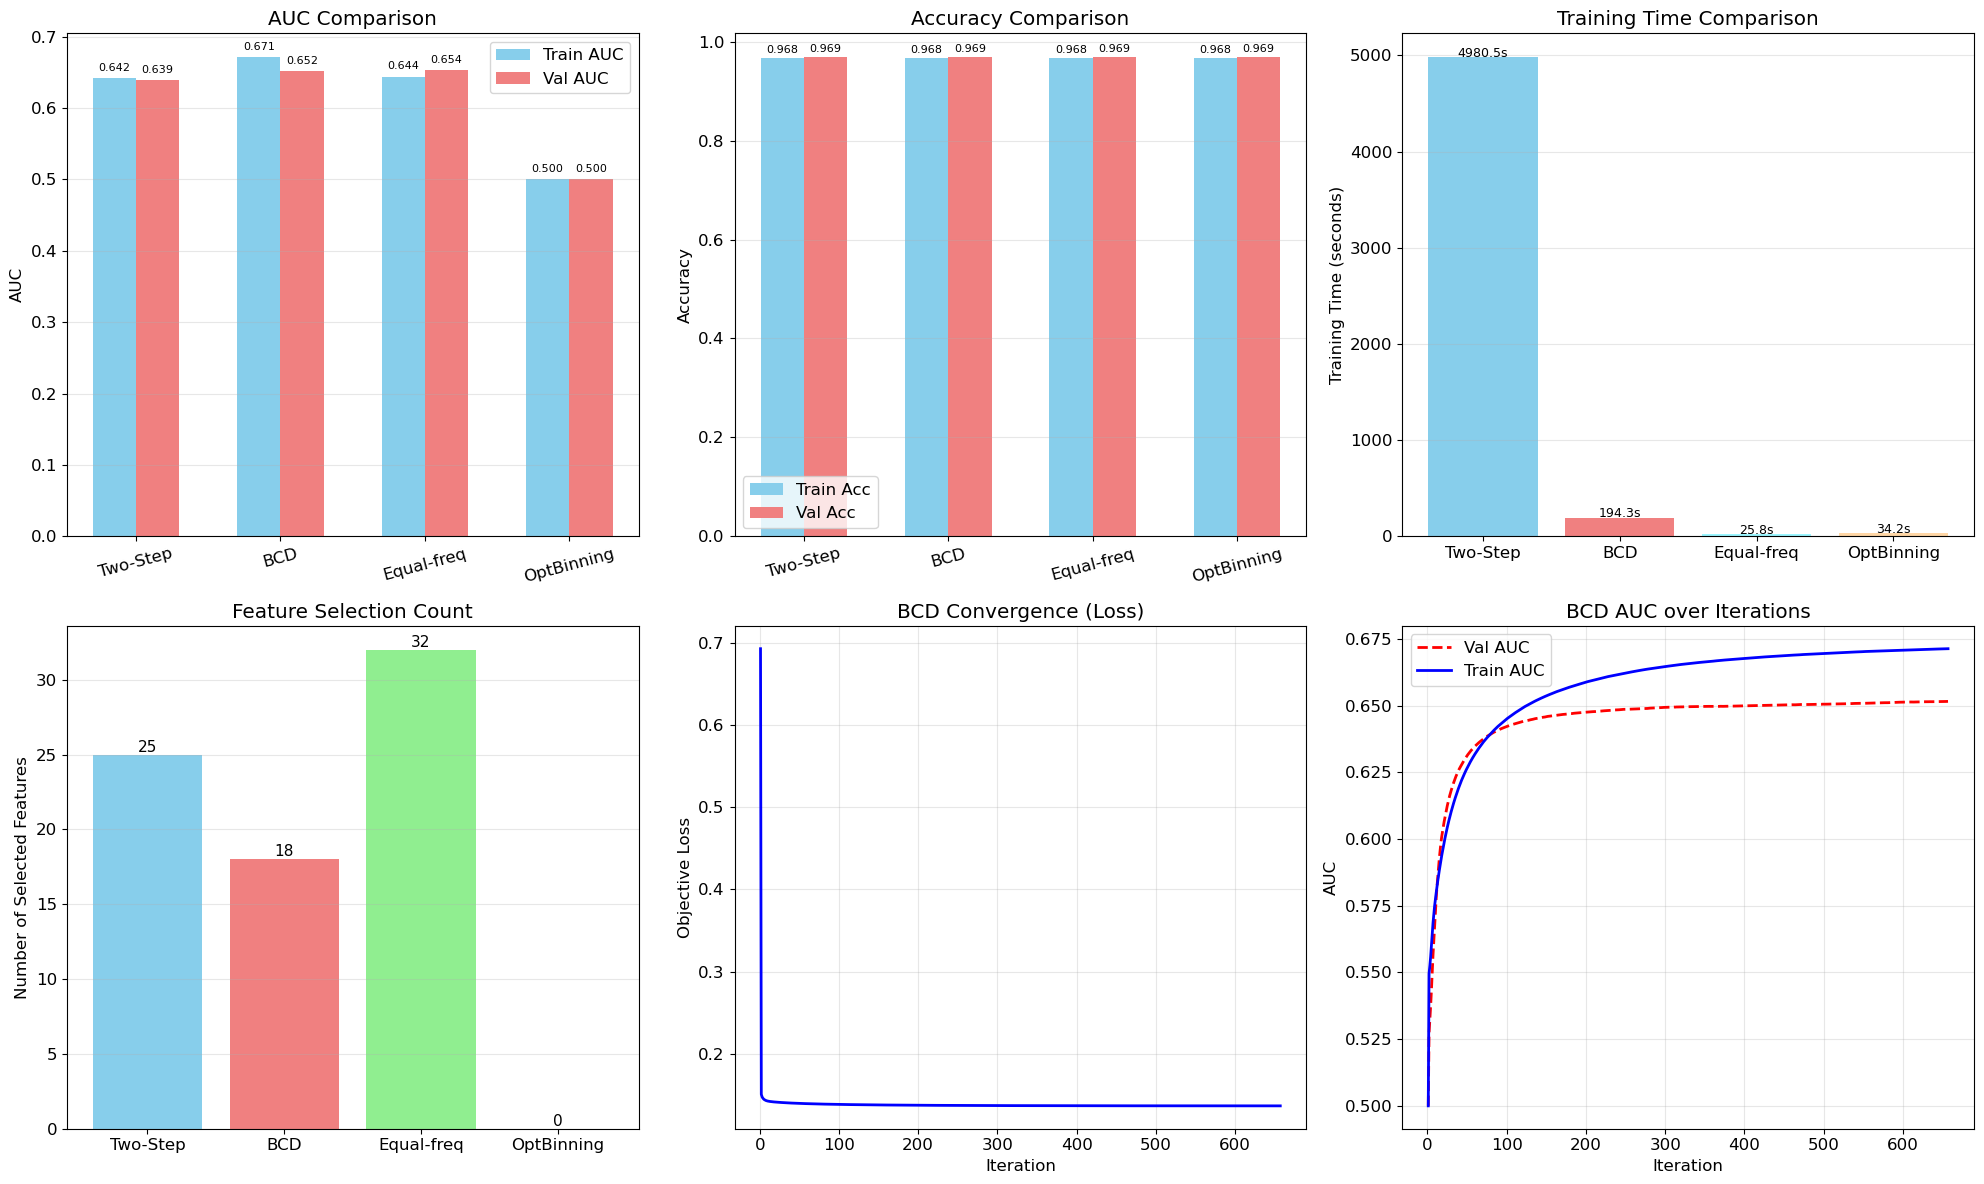

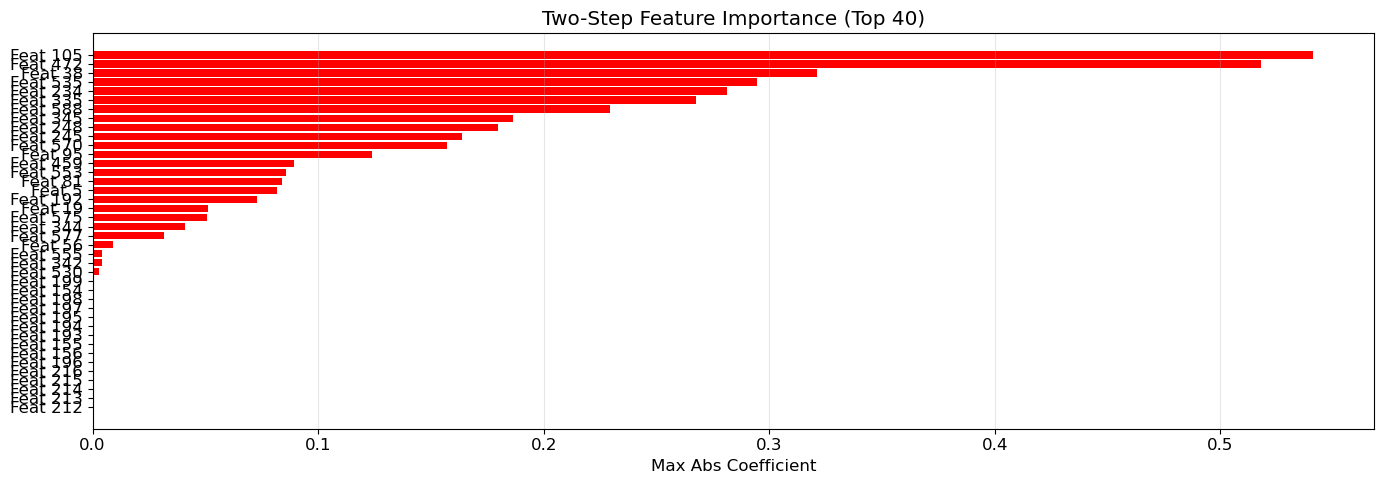

可视化图表已生成并保存：results_comparison.png 和 two_step_importance.png


In [6]:
# ===================== 追加：可视化实验对比结果 =====================
import matplotlib.pyplot as plt
import numpy as np

# 确保中文或英文显示正常，这里使用英文
plt.rcParams['font.size'] = 12

# 1. 创建画布：2 行 3 列
fig, axes = plt.subplots(2, 3, figsize=(20, 12))

# --- 子图 1：AUC 对比 ---
ax = axes[0, 0]
x = np.arange(len(methods))
width = 0.3
ax.bar(x - width/2, train_aucs_all, width, label='Train AUC', color='skyblue')
ax.bar(x + width/2, val_aucs_all, width, label='Val AUC', color='lightcoral')
ax.set_xticks(x)
ax.set_xticklabels(methods, rotation=15)
ax.set_ylabel('AUC')
ax.set_title('AUC Comparison')
ax.legend()
ax.grid(axis='y', alpha=0.3)
# 标数值
for i in range(len(methods)):
    ax.text(i - width/2, train_aucs_all[i] + 0.01, f'{train_aucs_all[i]:.3f}', ha='center', fontsize=8)
    ax.text(i + width/2, val_aucs_all[i] + 0.01, f'{val_aucs_all[i]:.3f}', ha='center', fontsize=8)

# --- 子图 2：Accuracy 对比 ---
ax = axes[0, 1]
ax.bar(x - width/2, train_accs_all, width, label='Train Acc', color='skyblue')
ax.bar(x + width/2, val_accs_all, width, label='Val Acc', color='lightcoral')
ax.set_xticks(x)
ax.set_xticklabels(methods, rotation=15)
ax.set_ylabel('Accuracy')
ax.set_title('Accuracy Comparison')
ax.legend()
ax.grid(axis='y', alpha=0.3)
for i in range(len(methods)):
    ax.text(i - width/2, train_accs_all[i] + 0.01, f'{train_accs_all[i]:.3f}', ha='center', fontsize=8)
    ax.text(i + width/2, val_accs_all[i] + 0.01, f'{val_accs_all[i]:.3f}', ha='center', fontsize=8)

# --- 子图 3：训练时间对比 ---
ax = axes[0, 2]
ax.bar(methods, times_all, color=['skyblue', 'lightcoral', '#9bf6ff', '#ffd6a5'])
ax.set_ylabel('Training Time (seconds)')
ax.set_title('Training Time Comparison')
ax.grid(axis='y', alpha=0.3)
for i, v in enumerate(times_all):
    ax.text(i, v + 2, f'{v:.1f}s', ha='center', fontsize=9)

# --- 子图 4：特征选择数量对比（含等频分箱和 OptBinning） ---
ax = axes[1, 0]
methods_sel = ['Two-Step', 'BCD', 'Equal-freq', 'OptBinning']
select_counts = [
    len(two_step_selected_features),
    len(bcd_selected_features),
    len(eq_selected_features),         # 已在等频分箱处定义
    len(opt_selected_features)         # 需要你在上面新增的 opt_selected_features
]
colors_sel = ['skyblue', 'lightcoral', 'lightgreen', 'plum']
bars = ax.bar(methods_sel, select_counts, color=colors_sel)
ax.set_ylabel('Number of Selected Features')
ax.set_title('Feature Selection Count')
ax.grid(axis='y', alpha=0.3)
for bar, v in zip(bars, select_counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2, str(v),
            ha='center', fontsize=11)

# --- 子图 5：BCD 收敛曲线（Loss） ---
ax = axes[1, 1]
if bcd_loss_history and len(bcd_loss_history) > 1:
    ax.plot(range(1, len(bcd_loss_history)+1), bcd_loss_history, 'b-', linewidth=2)
    ax.set_xlabel('Iteration')
    ax.set_ylabel('Objective Loss')
    ax.set_title('BCD Convergence (Loss)')
    ax.grid(alpha=0.3)
else:
    ax.text(0.5, 0.5, 'No loss history available', ha='center', va='center')
    ax.set_title('BCD Convergence')

# --- 子图 6：BCD 验证 AUC 随迭代变化（如果 history 中有记录） ---
ax = axes[1, 2]
val_auc_hist = bcd_model.history.get('metric_val', [])
if val_auc_hist and len(val_auc_hist) > 1:
    ax.plot(range(1, len(val_auc_hist)+1), val_auc_hist, 'r--', linewidth=2, label='Val AUC')
    ax.plot(range(1, len(bcd_model.history['metric_train'])+1),
            bcd_model.history['metric_train'], 'b-', linewidth=2, label='Train AUC')
    ax.set_xlabel('Iteration')
    ax.set_ylabel('AUC')
    ax.set_title('BCD AUC over Iterations')
    ax.legend()
    ax.grid(alpha=0.3)
else:
    ax.text(0.5, 0.5, 'No validation AUC history', ha='center', va='center')
    ax.set_title('BCD AUC History')

plt.tight_layout()
plt.savefig('results_comparison.png', dpi=150)
plt.show()

# 额外：两步法特征重要性图（前 40 个）
plt.figure(figsize=(14, 5))
importances = two_step_model.feature_importances
n_show = min(40, len(importances))
top_idx = np.argsort(importances)[-n_show:]
plt.barh(range(n_show), importances[top_idx], 
         color=['red' if two_step_model.feature_selected[i] else 'blue' for i in top_idx])
plt.yticks(range(n_show), [f'Feat {i+1}' for i in top_idx])
plt.xlabel('Max Abs Coefficient')
plt.title(f'Two-Step Feature Importance (Top {n_show})')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('two_step_importance.png', dpi=150)
plt.show()

print("可视化图表已生成并保存：results_comparison.png 和 two_step_importance.png")

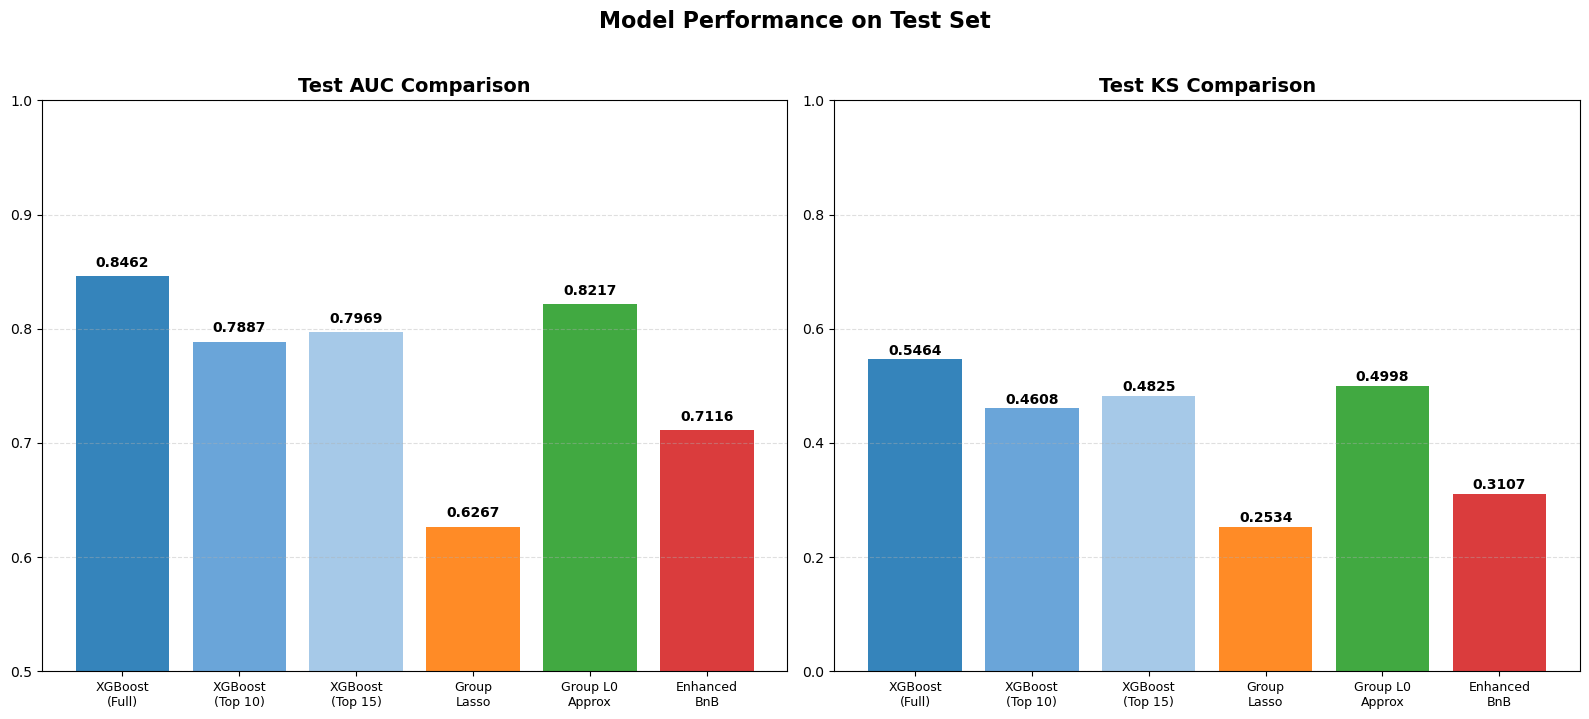

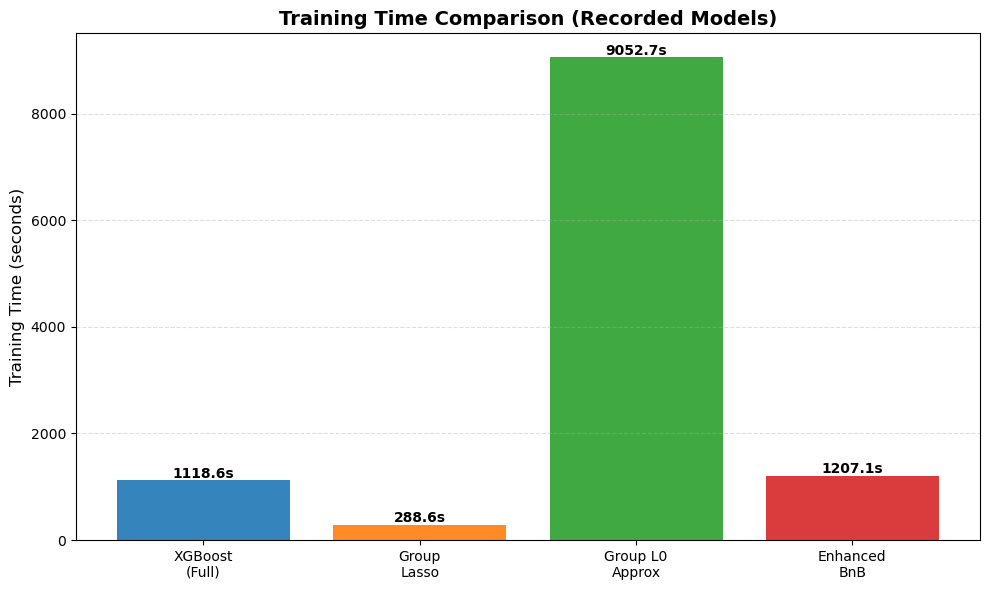

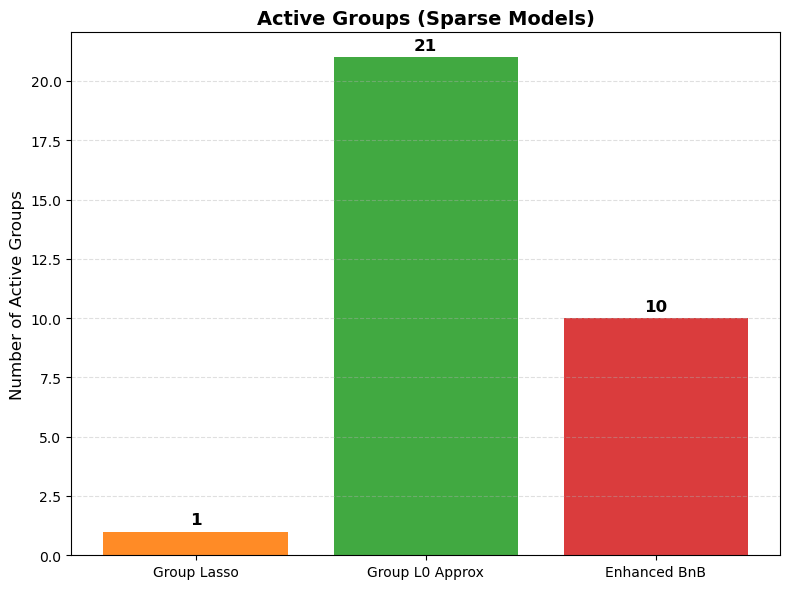

三幅图已保存：
  1_test_auc_ks.png  (AUC & KS)
  2_training_time.png (训练时间，仅含已记录模型)
  3_active_groups.png (稀疏模型激活组数)


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ==================== 数据：使用新跑出的 GroupL0Logistic 结果替换原 Group L0 Approx ====================
model_names = [
    'XGBoost\n(Full)',
    'XGBoost\n(Top 10)',
    'XGBoost\n(Top 15)',
    'Group\nLasso',
    'Group L0\nApprox',      # ← 已更新为新结果
    'Enhanced\nBnB'
]

# Test AUC 和 Test KS：来自您认可的表格，仅 Group L0 Approx 用新值
test_auc = [0.8462, 0.7887, 0.7969, 0.6267, 0.8217, 0.7116]
test_ks  = [0.5464, 0.4608, 0.4825, 0.2534, 0.4998, 0.3107]

# 训练时间 (秒)：XGBoost Full=1118.57, Group Lasso=288.64, Group L0 Approx=9052.67(新), Enhanced BnB=1207.09
# XGBoost Top10/Top15 未记录，设为0并过滤
time_s = [1118.57, 0, 0, 288.64, 9052.67, 1207.09]

# 激活组数（仅稀疏模型）
active_groups = [None, None, None, 1, 21, 10]   # 21 来自新结果

# 颜色
colors = ['#1f77b4', '#5a9bd5', '#9dc3e6', '#ff7f0e', '#2ca02c', '#d62728']

# ==================== 图1：Test AUC 和 Test KS 并排柱状图 ====================
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# AUC
axes[0].bar(range(len(model_names)), test_auc, color=colors, alpha=0.9)
axes[0].set_title('Test AUC Comparison', fontsize=14, fontweight='bold')
axes[0].set_ylim(0.5, 1.0)
axes[0].set_xticks(range(len(model_names)))
axes[0].set_xticklabels(model_names, fontsize=9)
axes[0].grid(axis='y', linestyle='--', alpha=0.4)
for i, v in enumerate(test_auc):
    axes[0].text(i, v + 0.008, f'{v:.4f}', ha='center', fontsize=10, fontweight='bold')

# KS
axes[1].bar(range(len(model_names)), test_ks, color=colors, alpha=0.9)
axes[1].set_title('Test KS Comparison', fontsize=14, fontweight='bold')
axes[1].set_ylim(0, 1.0)
axes[1].set_xticks(range(len(model_names)))
axes[1].set_xticklabels(model_names, fontsize=9)
axes[1].grid(axis='y', linestyle='--', alpha=0.4)
for i, v in enumerate(test_ks):
    axes[1].text(i, v + 0.008, f'{v:.4f}', ha='center', fontsize=10, fontweight='bold')

fig.suptitle('Model Performance on Test Set', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('1_test_auc_ks.png', dpi=300, bbox_inches='tight')
plt.show()

# ==================== 图2：训练时间对比（仅绘制有记录的模型） ====================
valid_idx = [i for i, t in enumerate(time_s) if t > 0]
valid_models = [model_names[i] for i in valid_idx]
valid_times = [time_s[i] for i in valid_idx]
valid_colors = [colors[i] for i in valid_idx]

plt.figure(figsize=(10, 6))
bars = plt.bar(valid_models, valid_times, color=valid_colors, alpha=0.9)
plt.ylabel('Training Time (seconds)', fontsize=12)
plt.title('Training Time Comparison (Recorded Models)', fontsize=14, fontweight='bold')
plt.grid(axis='y', linestyle='--', alpha=0.4)
for bar, v in zip(bars, valid_times):
    plt.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 50,
             f'{v:.1f}s', ha='center', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.savefig('2_training_time.png', dpi=300, bbox_inches='tight')
plt.show()

# ==================== 图3：稀疏模型激活组数 ====================
sparse_idx = [3, 4, 5]   # Group Lasso, Group L0 Approx, Enhanced BnB
sparse_models = [model_names[i].replace('\n', ' ') for i in sparse_idx]
sparse_groups = [active_groups[i] for i in sparse_idx]
sparse_colors = [colors[i] for i in sparse_idx]

plt.figure(figsize=(8, 6))
bars = plt.bar(sparse_models, sparse_groups, color=sparse_colors, alpha=0.9)
plt.ylabel('Number of Active Groups', fontsize=12)
plt.title('Active Groups (Sparse Models)', fontsize=14, fontweight='bold')
plt.grid(axis='y', linestyle='--', alpha=0.4)
for bar, v in zip(bars, sparse_groups):
    plt.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.3,
             str(v), ha='center', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('3_active_groups.png', dpi=300, bbox_inches='tight')
plt.show()

print("三幅图已保存：")
print("  1_test_auc_ks.png  (AUC & KS)")
print("  2_training_time.png (训练时间，仅含已记录模型)")
print("  3_active_groups.png (稀疏模型激活组数)")

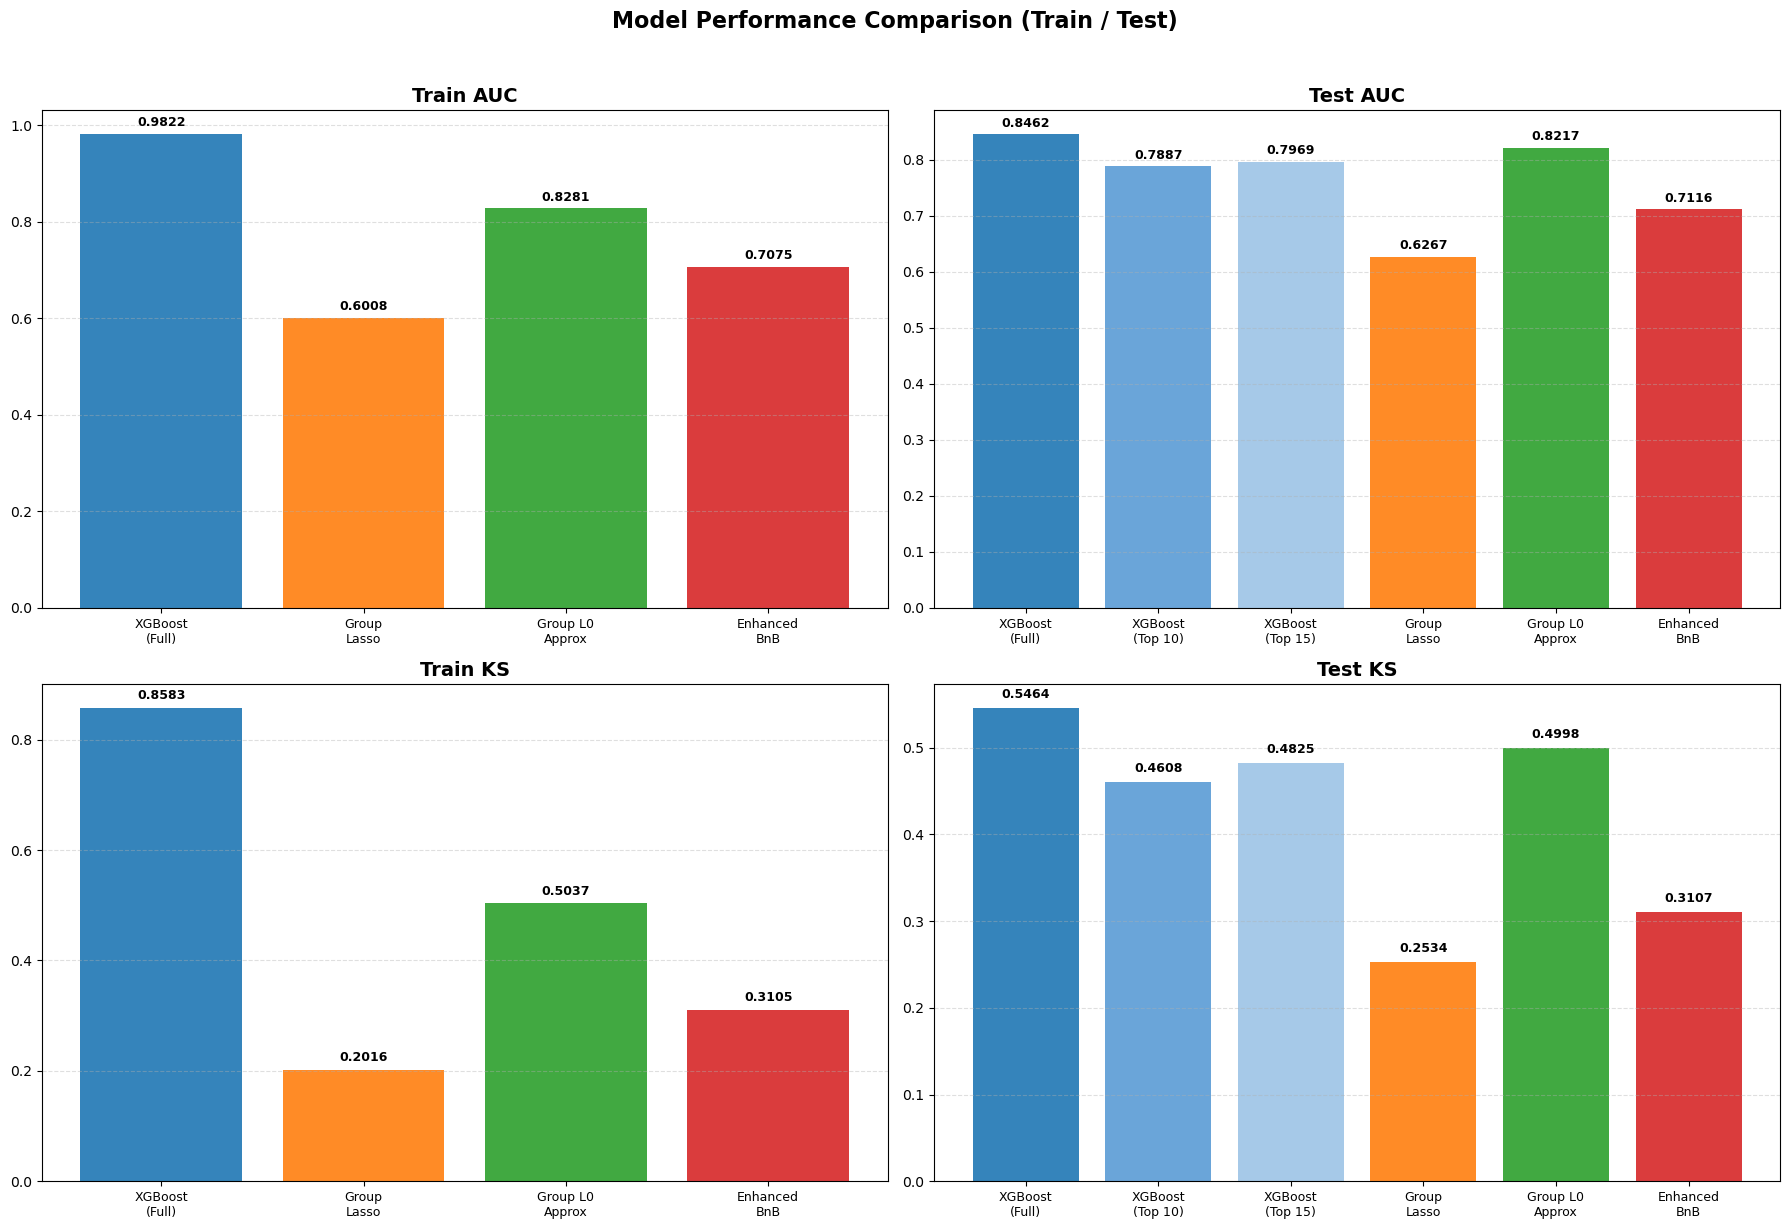

2×2 对比图已保存为 model_performance_2x2_clean.png


In [5]:
import numpy as np
import matplotlib.pyplot as plt

# ==================== 全部数据 ====================
all_models = [
    'XGBoost\n(Full)',
    'XGBoost\n(Top 10)',
    'XGBoost\n(Top 15)',
    'Group\nLasso',
    'Group L0\nApprox',
    'Enhanced\nBnB'
]

# 训练集指标（只有部分模型有数据）
train_models = ['XGBoost\n(Full)', 'Group\nLasso', 'Group L0\nApprox', 'Enhanced\nBnB']
train_auc_vals = [0.9822, 0.6008, 0.8281, 0.7075]
train_ks_vals  = [0.8583, 0.2016, 0.5037, 0.3105]

# 测试集指标（全部六个模型）
test_auc_vals = [0.8462, 0.7887, 0.7969, 0.6267, 0.8217, 0.7116]
test_ks_vals  = [0.5464, 0.4608, 0.4825, 0.2534, 0.4998, 0.3107]

# 原始颜色（六种）
colors_all = ['#1f77b4', '#5a9bd5', '#9dc3e6', '#ff7f0e', '#2ca02c', '#d62728']
# 训练集对应的颜色：从全部颜色中按索引取出 [0, 3, 4, 5]
train_colors = [colors_all[i] for i in [0, 3, 4, 5]]

# ==================== 绘制 2x2 子图 ====================
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# 子图1：训练集 AUC（仅4个模型）
ax = axes[0, 0]
x_train = np.arange(len(train_models))
bars = ax.bar(x_train, train_auc_vals, color=train_colors, alpha=0.9)
ax.set_title('Train AUC', fontsize=14, fontweight='bold')
ax.set_xticks(x_train)
ax.set_xticklabels(train_models, fontsize=9)
ax.grid(axis='y', linestyle='--', alpha=0.4)
for bar, v in zip(bars, train_auc_vals):
    ax.text(bar.get_x() + bar.get_width()/2., v + 0.01, f'{v:.4f}',
            ha='center', va='bottom', fontsize=9, fontweight='bold')

# 子图2：测试集 AUC（全部6个模型）
ax = axes[0, 1]
x_all = np.arange(len(all_models))
bars = ax.bar(x_all, test_auc_vals, color=colors_all, alpha=0.9)
ax.set_title('Test AUC', fontsize=14, fontweight='bold')
ax.set_xticks(x_all)
ax.set_xticklabels(all_models, fontsize=9)
ax.grid(axis='y', linestyle='--', alpha=0.4)
for bar, v in zip(bars, test_auc_vals):
    ax.text(bar.get_x() + bar.get_width()/2., v + 0.008, f'{v:.4f}',
            ha='center', va='bottom', fontsize=9, fontweight='bold')

# 子图3：训练集 KS（仅4个模型）
ax = axes[1, 0]
bars = ax.bar(x_train, train_ks_vals, color=train_colors, alpha=0.9)
ax.set_title('Train KS', fontsize=14, fontweight='bold')
ax.set_xticks(x_train)
ax.set_xticklabels(train_models, fontsize=9)
ax.grid(axis='y', linestyle='--', alpha=0.4)
for bar, v in zip(bars, train_ks_vals):
    ax.text(bar.get_x() + bar.get_width()/2., v + 0.01, f'{v:.4f}',
            ha='center', va='bottom', fontsize=9, fontweight='bold')

# 子图4：测试集 KS（全部6个模型）
ax = axes[1, 1]
bars = ax.bar(x_all, test_ks_vals, color=colors_all, alpha=0.9)
ax.set_title('Test KS', fontsize=14, fontweight='bold')
ax.set_xticks(x_all)
ax.set_xticklabels(all_models, fontsize=9)
ax.grid(axis='y', linestyle='--', alpha=0.4)
for bar, v in zip(bars, test_ks_vals):
    ax.text(bar.get_x() + bar.get_width()/2., v + 0.008, f'{v:.4f}',
            ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.suptitle('Model Performance Comparison (Train / Test)', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('model_performance_2x2_clean.png', dpi=300, bbox_inches='tight')
plt.show()

print("2×2 对比图已保存为 model_performance_2x2_clean.png")